In [3]:
import scanpy as sc
import mudata as md
import muon as mu
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import median_abs_deviation
from plotnine import ggplot, aes, theme_bw, geom_bin2d, scale_fill_cmap,facet_wrap

import datetime
from decimal import Decimal
import os
from pathlib import Path
from glob import glob
from tqdm import tqdm
from multiprocessing import Pool

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png',frameon=False)
sc._settings.ScanpyConfig.n_jobs=4
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
np.random.seed(1)

In [2]:
sc.logging.print_header()

Package,Version
scanpy,1.11.0
mudata,0.3.1
muon,0.1.6
anndata,0.11.3
pandas,2.2.3
matplotlib,3.9.2
seaborn,0.13.2
numpy,1.26.4
scipy,1.15.2
plotnine,0.14.5


In [7]:
obj_path = '/home/liyanguo/MyImmuCell/02_Read_QC/'
sc.settings.figdir = obj_path

# 1. Read data

## 1.1 CITE-seq RNA

In [4]:
adata = sc.read_h5ad(f"{obj_path}scRNA_MyImmuCell_low_nCount_RNA.h5ad",backed='r')#backed mode

## 1.2 CITE-seq adt

In [5]:
adt = sc.read_h5ad(f"{obj_path}scADT_filtered_MyImmuCell.h5ad")

In [6]:
adt = adt[adata.obs_names,:].copy()

In [7]:
MyImmuCell_sample_info = pd.read_csv("/home/liyanguo/MyImmuCell/01_rawdata/MyImmuCell_sample_info.csv",usecols=[1, 2])

In [8]:
adt.obs = adt.obs.join(MyImmuCell_sample_info.set_index("SampleID"),on= 'SampleID',how='left')

In [9]:
# Cells with Higher RNA UMI detection from scRNA may have or not have higher ADT UMI detection, should be QC separately

In [10]:
adt

AnnData object with n_obs × n_vars = 36453806 × 30
    obs: 'orig.ident', 'SampleID', 'DonorID', 'Batch'

In [11]:
adt.X = adt.X.toarray()

# 2. QC of CITE-seq RNA data with lower UMI, Primarily composed by PBMC

In [12]:
def is_outlier(anndata, metric: str, nmads: int):
    M = np.log2(anndata.obs[metric]+1)
    outlier_low1 = np.median(M) - nmads * median_abs_deviation(M)
    outlier_high1 = np.median(M) + nmads * median_abs_deviation(M)
    
    outlier_low = round(2 ** outlier_low1,0)
    outlier_high = round(2 ** outlier_high1,0)
    return outlier_low,outlier_high

In [13]:
nCount_RNA_low, nCount_RNA_high = is_outlier(adata, "nCount_RNA", 4)
nFeature_RNA_low, nFeature_RNA_high = is_outlier(adata, "nFeature_RNA", 4)

In [14]:
nCount_RNA_low,nCount_RNA_high, nFeature_RNA_low,nFeature_RNA_high

(396.0, 3491.0, 291.0, 1483.0)

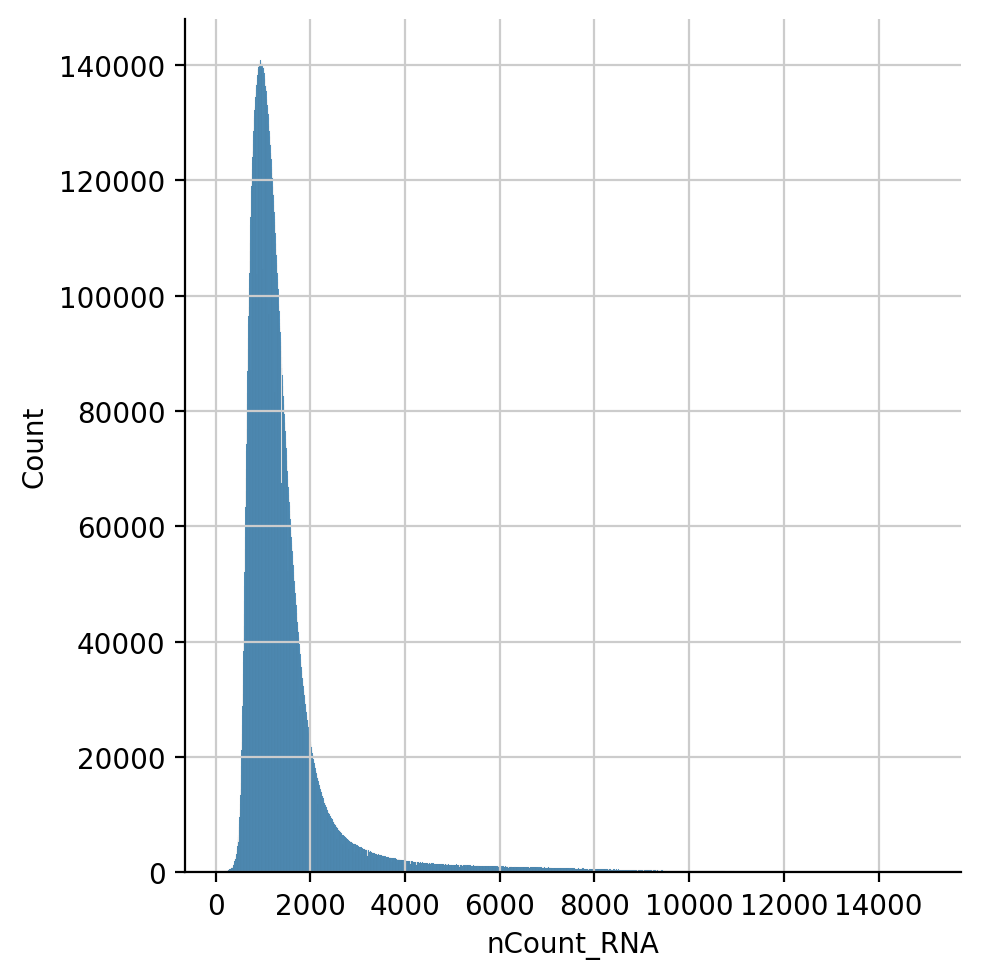

In [15]:
sns.displot(
    adata.obs.query("nCount_RNA > 0 and nCount_RNA < 15000").nCount_RNA
)

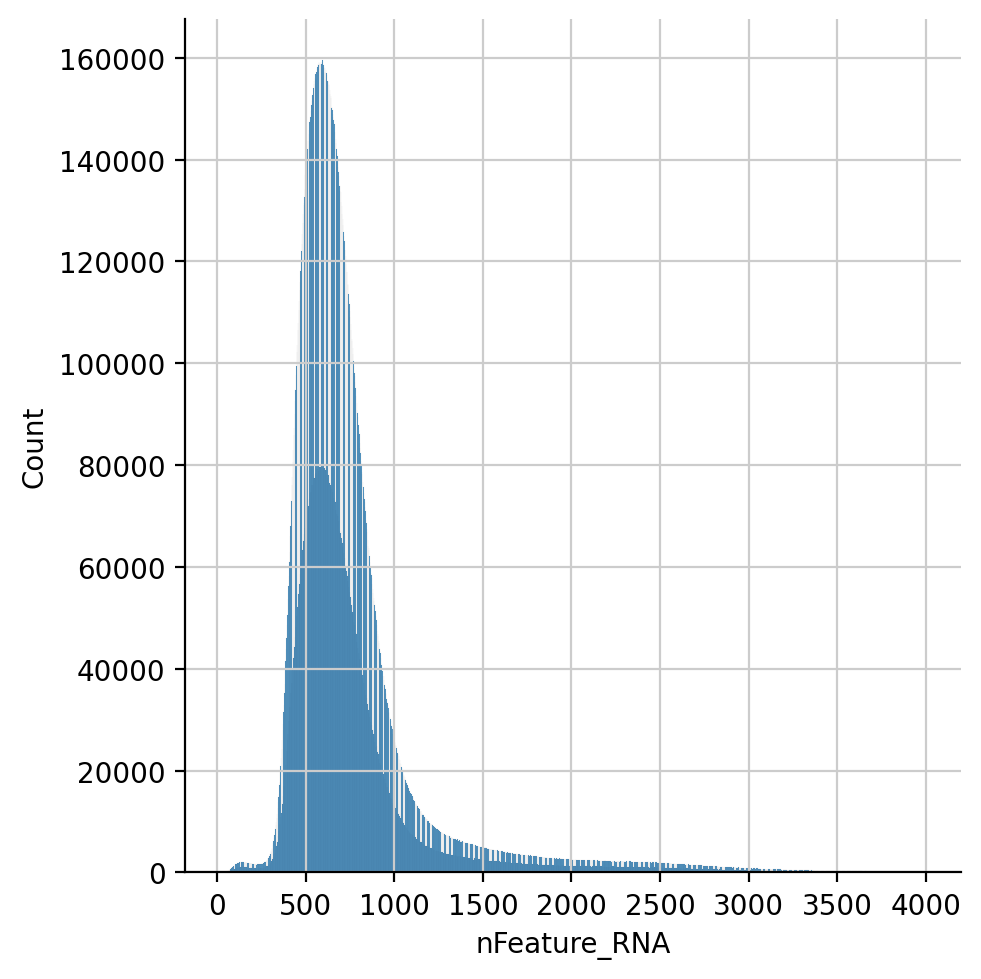

In [16]:
sns.displot(
    adata.obs.query("nFeature_RNA > 0 and nFeature_RNA < 4000").nFeature_RNA
)

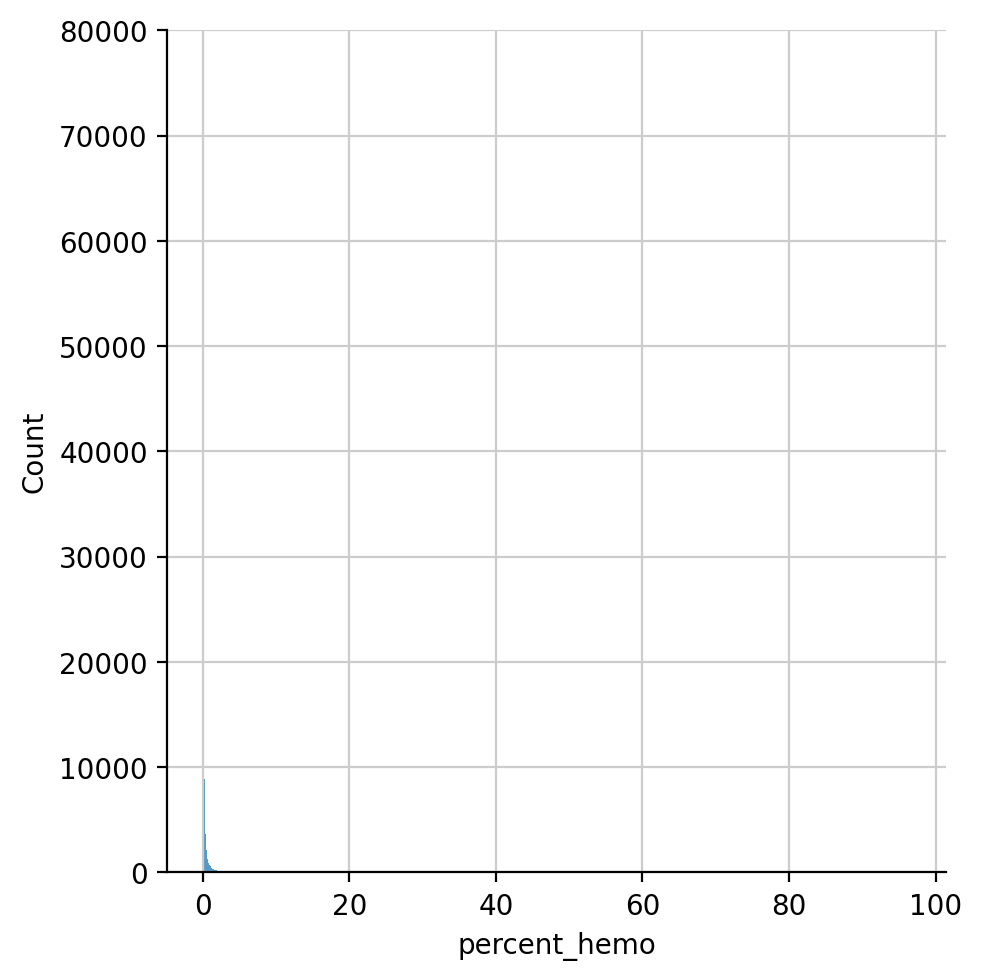

In [17]:
sns.displot(
    adata.obs.query("percent_hemo > 0 and percent_hemo < 100").percent_hemo
)

In [18]:
print(
    (adata.obs["percent_mito"] < 10).value_counts(),
    (adata.obs["nFeature_RNA"] > nFeature_RNA_low).value_counts(),
    (adata.obs["nFeature_RNA"] < nFeature_RNA_high).value_counts(),
    (adata.obs["nCount_RNA"] > nCount_RNA_low).value_counts(),
    (adata.obs["nCount_RNA"] < nCount_RNA_high).value_counts(),
    (adata.obs["percent_hemo"] < 1).value_counts(),
    (adata.obs["scDblFinder.class"] == "singlet").value_counts()
    )

percent_mito
True     36177820
False      275986
Name: count, dtype: int64 nFeature_RNA
True     36255289
False      198517
Name: count, dtype: int64 nFeature_RNA
True     34469134
False     1984672
Name: count, dtype: int64 nCount_RNA
True     36419334
False       34472
Name: count, dtype: int64 nCount_RNA
True     34695251
False     1758555
Name: count, dtype: int64 percent_hemo
True     35984523
False      469283
Name: count, dtype: int64 scDblFinder.class
True     33071414
False     3382392
Name: count, dtype: int64


In [19]:
decision = (adata.obs["nFeature_RNA"] > nFeature_RNA_low) & (
    adata.obs["nFeature_RNA"] < nFeature_RNA_high) & (
    adata.obs["percent_mito"] < 10) & (adata.obs["nCount_RNA"] > nCount_RNA_low) & (
    adata.obs["nCount_RNA"] < nCount_RNA_high) & (
    adata.obs["percent_hemo"] <1)

In [20]:
decision.value_counts()

True     33683499
False     2770307
Name: count, dtype: int64

In [21]:
# To avoid over-filtering of fragile immune cell populations.

# 1. log10GenesPerUMI
# We recommend do not filter with log10GenesPerUMI metric , 
# as low-quality cell populations can be reliably identified during downstream clustering analysis.

# 2. erythrocyte
# Apply lenient filtering: retain cells with adata.obs["total_counts_hb"] < 10


# 3. Neutrophils
# Neutrophils (Neu) are multi-lobed nuclear morphology mimics doublet signals,
# We not perform doublet removal procedures in QC until cell type annotation with multiple cell type marker highly expressed
# Neutrophils will have 200-1000 with mean 500 gene detection and >500 UMIs.
adata.obs["High_quality"] = (adata.obs["nFeature_RNA"] > nFeature_RNA_low) & (
    adata.obs["nFeature_RNA"] < nFeature_RNA_high) & (
    adata.obs["percent_mito"] < 10) & (adata.obs["nCount_RNA"] > nCount_RNA_low) & (
    adata.obs["nCount_RNA"] < nCount_RNA_high) & (
    adata.obs["percent_hemo"] < 1)

In [22]:
adata.obs["High_quality"].value_counts()

High_quality
True     33683499
False     2770307
Name: count, dtype: int64

## 1.1 Do the filtering of scRNA PBMC

In [23]:
print(f"Total number of cells before QC: {adata.n_obs}")
adata = adata[adata.obs.High_quality]#backed mode
print(f"Total number of cells after QC: {adata.n_obs}")

Total number of cells before QC: 36453806
Total number of cells after QC: 33683499


# 3. QC of single-cell antibody capture

In [24]:
sc.pp.calculate_qc_metrics(adt, inplace=True, percent_top=None,log1p=True)

In [25]:
adt.obs['total_counts'].describe()#nCount_ADT, part of cell did not detected any protein

count    3.645381e+07
mean     9.841927e+02
std      8.952358e+02
min      0.000000e+00
25%      5.470000e+02
50%      8.170000e+02
75%      1.206000e+03
max      9.141110e+05
Name: total_counts, dtype: float64

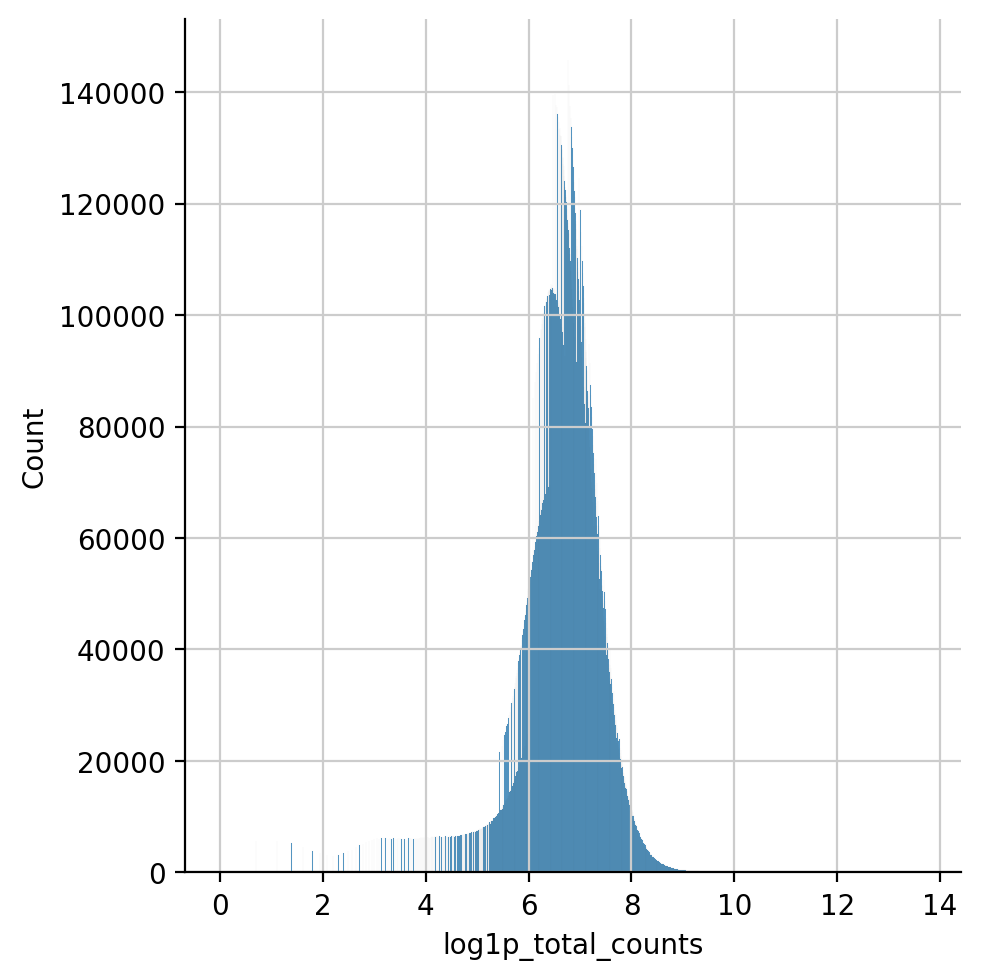

In [26]:
sns.displot(adt.obs.log1p_total_counts)

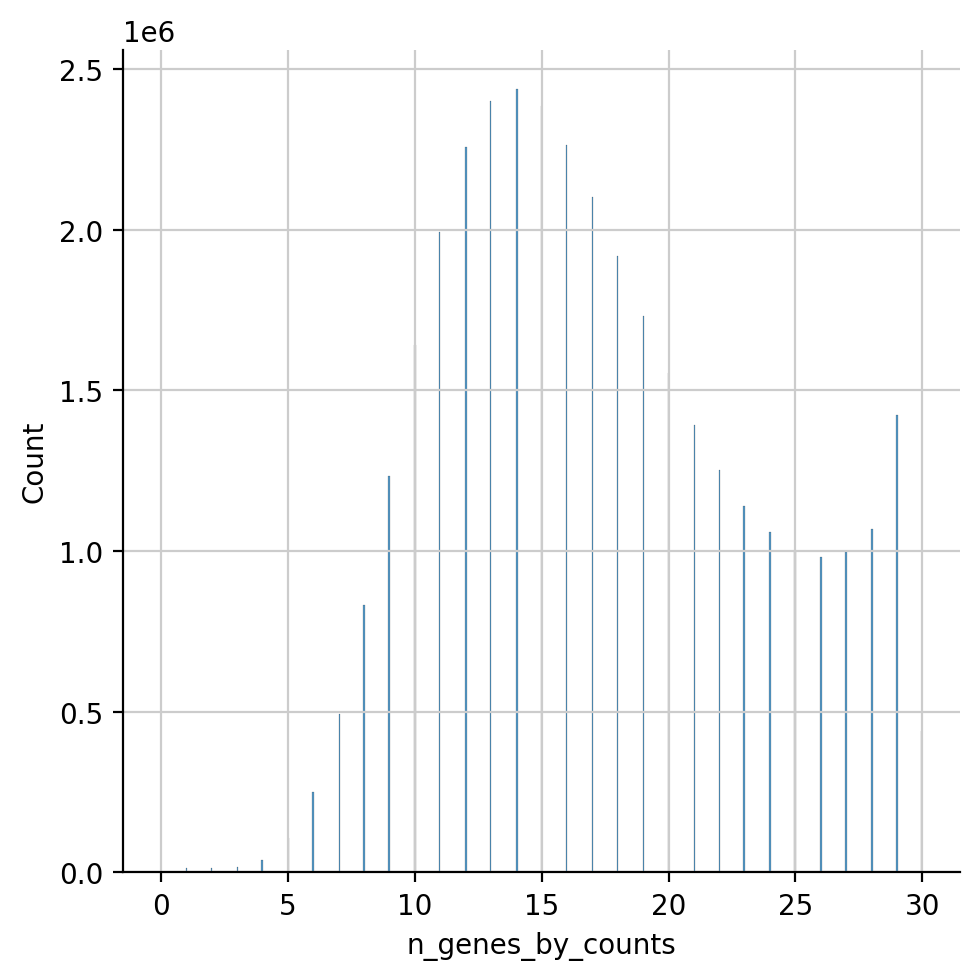

In [27]:
sns.displot(adt.obs.n_genes_by_counts)

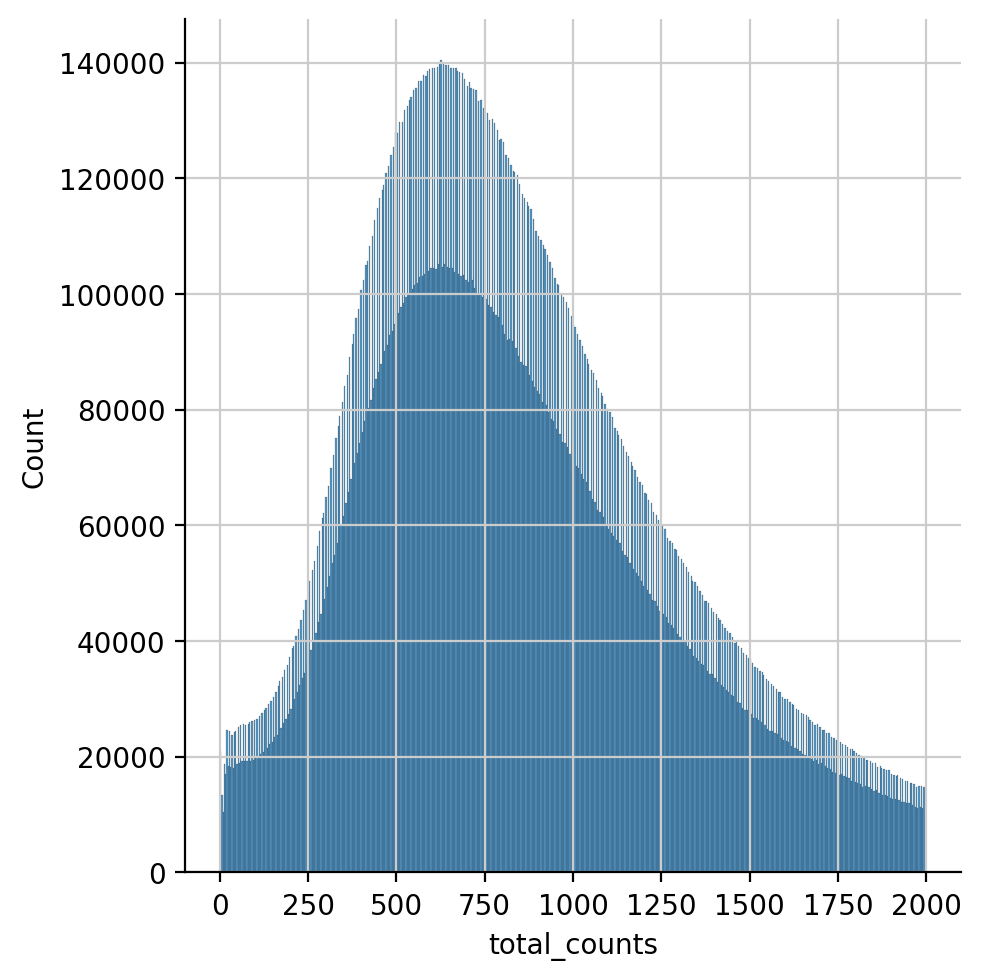

In [37]:
sns.displot(
    adt.obs.query("total_counts > 0 and total_counts < 2000").total_counts
)

In [29]:
def is_outlier(anndata, metric: str, nmads: int):
    M = np.log2(anndata.obs[metric]+1)
    outlier_low1 = np.median(M) - nmads * median_abs_deviation(M)
    outlier_high1 = np.median(M) + nmads * median_abs_deviation(M)
    outlier_low = round(2 ** outlier_low1,0)
    outlier_high = round(2 ** outlier_high1,0)
    return outlier_low, outlier_high

In [40]:
total_counts_low, total_counts_high = is_outlier(adt, "total_counts", 4)
n_genes_by_counts_low, n_genes_by_counts_high = is_outlier(adt, "n_genes_by_counts", 4)# max 30 protein

In [41]:
total_counts_low, total_counts_high, n_genes_by_counts_low, n_genes_by_counts_high

(169.0, 3955.0, 6.0, 50.0)

In [46]:
decision = (adt.obs["total_counts"] > total_counts_low) & (adt.obs["total_counts"] < total_counts_high) & (adt.obs["n_genes_by_counts"] > 5)

In [47]:
decision.value_counts()

True     34965904
False     1487902
Name: count, dtype: int64

In [48]:
adt.obs["High_quality"] = (adt.obs["total_counts"] > total_counts_low) & (adt.obs["total_counts"] < total_counts_high) & (adt.obs["n_genes_by_counts"] > 5)

In [49]:
adt.obs["High_quality"].value_counts()

High_quality
True     34965904
False     1487902
Name: count, dtype: int64

## 3.1 Do the filtering of ADT

In [51]:
print ('Do the filtering')
print(f"Total number of cells before QC: {adt.n_obs}")
tmp = adt[adt.obs.High_quality].copy()
print(f"Total number of cells after QC: {tmp.n_obs}")

Do the filtering
Total number of cells before QC: 36453806
Total number of cells after QC: 34965904


In [52]:
len(adata.obs_names.intersection(tmp.obs_names))

32504748

In [53]:
adt = tmp.copy()
del tmp

## 3.2 dsb clr Normalization

In [54]:
adt.write_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/tmp_scADT_filtered_MyImmuCell_low_nCount_RNA.h5ad",compression="gzip")

In [ ]:
# Shell, conda env. . 48h for 3000M cells
# nohup /home/liyanguo/anaconda3/envs/R/bin/python dsb_clr.py low_nCount_RNA &

# 3.3 dsb clr Normalization

In [55]:
adt.layers["clr"] = mu.prot.pp.clr(adt,inplace= False).X.copy()

## 3.3 Detect heterotypic doublet using cell type specific surface marker

In [56]:
adt.X.max()

3863.0

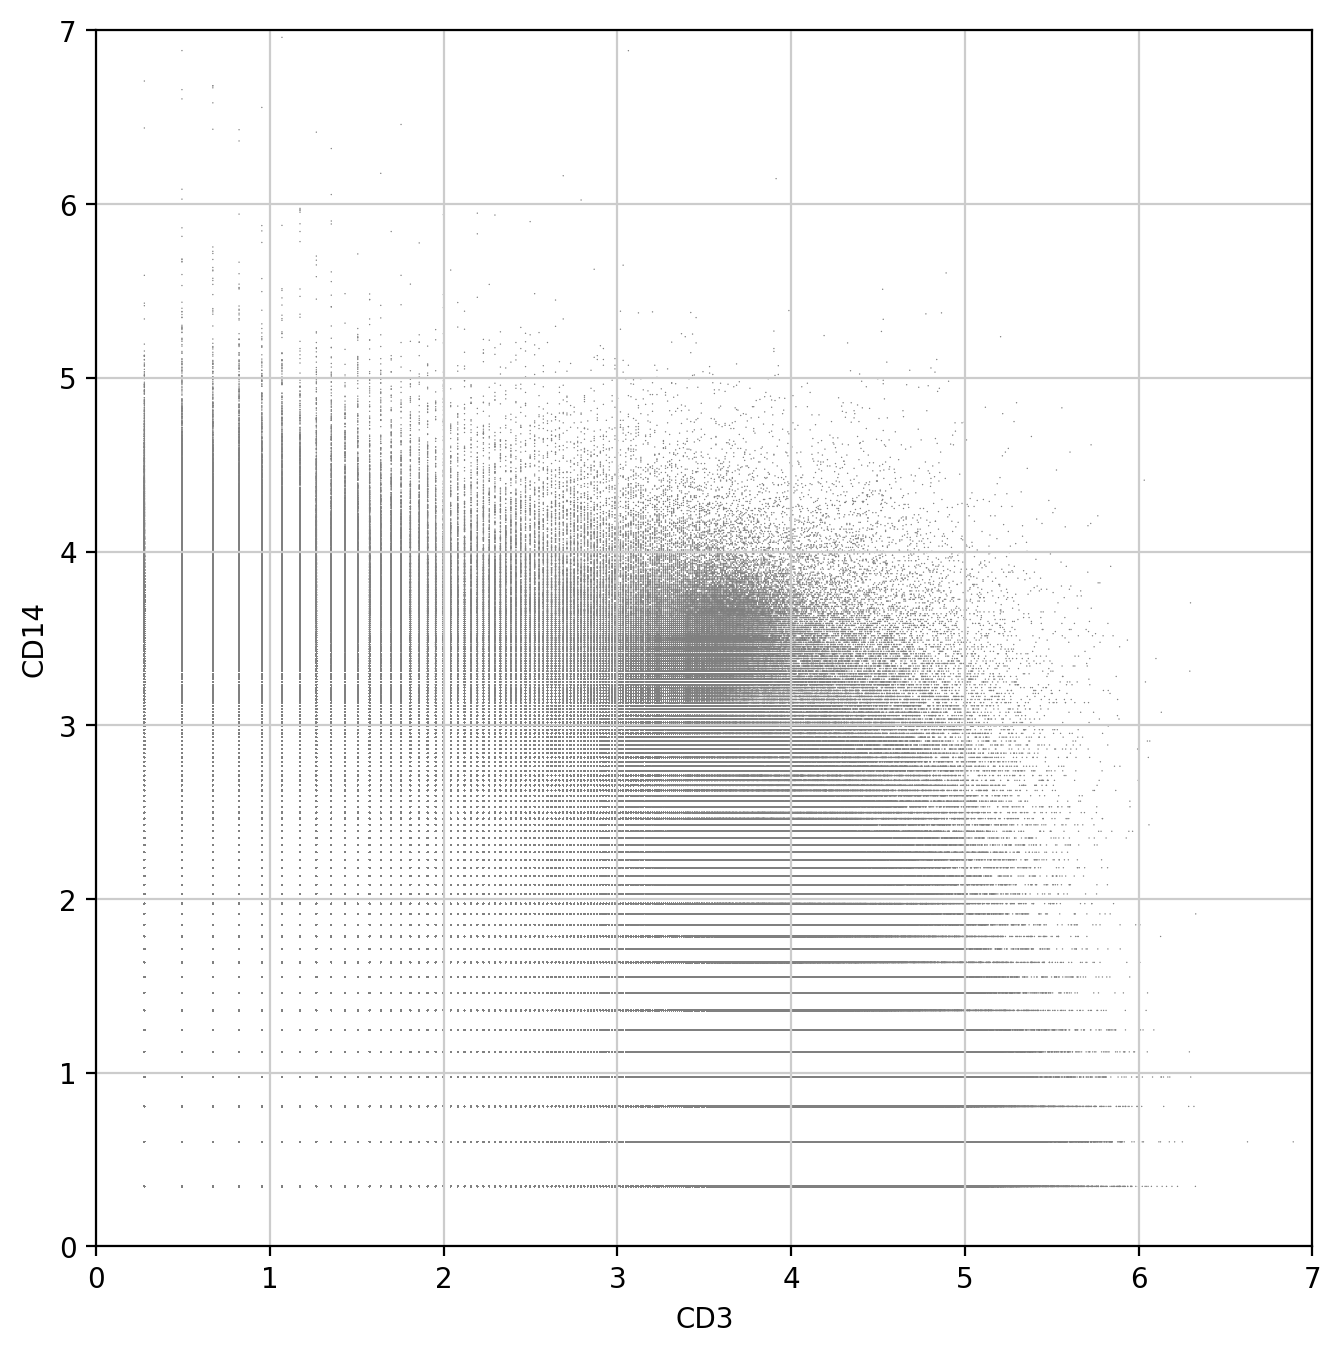

In [72]:
fig, ax = plt.subplots()
sc.pl.scatter(adt, x="CD3", y="CD14",size=1,layers='clr',ax=ax, show=False)
ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.set_aspect('equal')
plt.show()

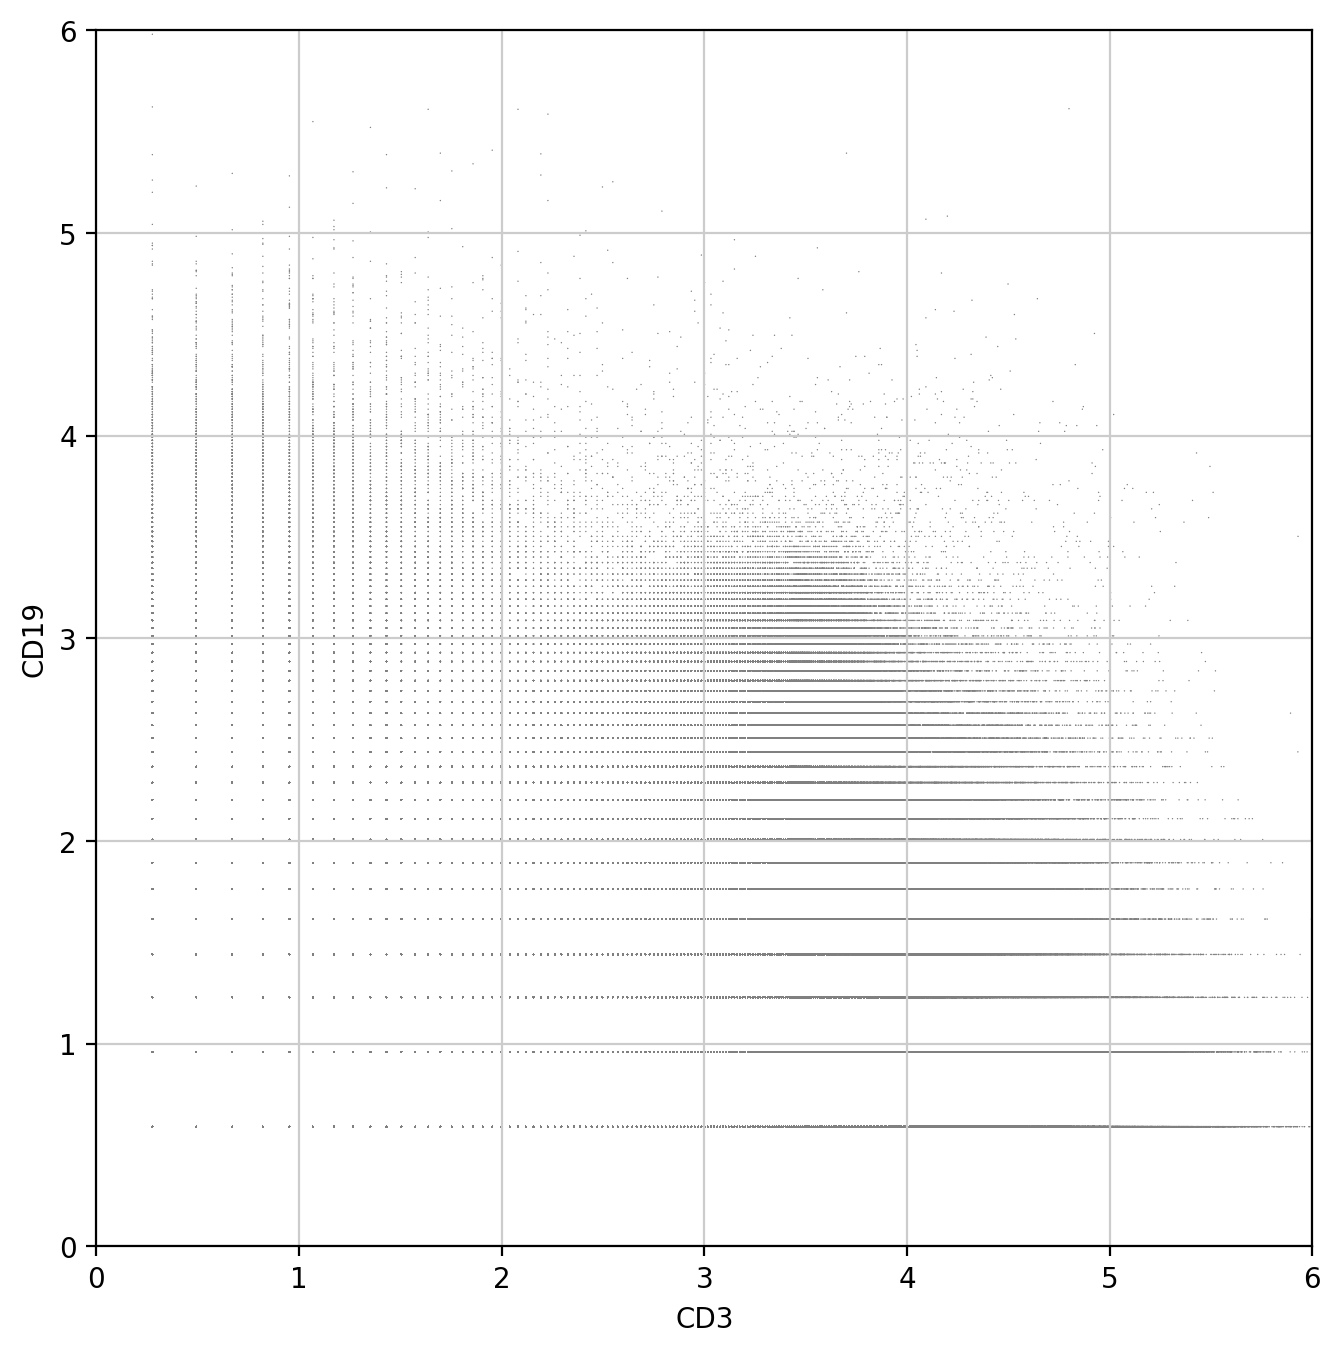

In [73]:
fig, ax = plt.subplots()
sc.pl.scatter(adt, x="CD3", y="CD19",size=1,layers='clr',ax=ax, show=False)
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
plt.show()

In [62]:
genes2filter = ["CD3", "CD19", "CD14"]
temp = adt[:, genes2filter].layers['clr'].T.tolist()

In [74]:
#It looks like the change in distribution is around choosed value. We could use an expression level above this value of at least two incompatible markers as our threshold to flag doublets.
adt.obs["doublets_by_markers"] = [
    (temp[0][i] > 3 and temp[1][i] > 3) or (temp[0][i] > 3 and temp[2][i] > 3)
    for i in range(adt.shape[0])
]

In [75]:
adt.obs["doublets_by_markers"] = (
    adt.obs["doublets_by_markers"].astype(str)
)

In [76]:
adt.obs["doublets_by_markers"].value_counts()

doublets_by_markers
False    34838182
True       127722
Name: count, dtype: int64

### 3.4.1 Do the filtering of ADT

In [78]:
print(f"Total number of cells before QC: {adt.n_obs}")
adt = adt[adt.obs["doublets_by_markers"]=="False"].copy()
print(f"Total number of cells after QC: {adt.n_obs}")

Total number of cells before QC: 34965904
Total number of cells after QC: 34838182


# 4 Preparing data for TOTALVI

## 4.1 Save CITE-seq adt

In [79]:
adt = adt[adt.obs_names.intersection(adata.obs_names),:].copy()#memory mode

In [80]:
adt

AnnData object with n_obs × n_vars = 32410257 × 30
    obs: 'orig.ident', 'SampleID', 'DonorID', 'Batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'High_quality', 'doublets_by_markers'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'doublets_by_markers_colors'
    layers: 'clr'

In [81]:
# for fast write and read

In [82]:
adt.X.max()

3863.0

In [83]:
adt.write("/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scADT_MyImmuCell_low_nCount_RNA.h5ad",compression="gzip")

## 4.2 Save CITE-seq rna

In [84]:
adata.isbacked

True

In [85]:
adata.copy('/home/liyanguo/MyImmuCell/02_Read_QC/tmp_scRNA_MyImmuCell_low_nCount_RNA.h5ad')

AnnData object with n_obs × n_vars = 33683499 × 38606 backed at '/home/liyanguo/MyImmuCell/02_Read_QC/tmp_scRNA_MyImmuCell_low_nCount_RNA.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'scDblFinder.class', 'High_quality'

In [86]:
adata.file.close()

## 4.3 Find highly_variable_genes

In [87]:
# Time elapse 1 hour

In [88]:
adt = sc.read_h5ad("/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scADT_MyImmuCell_low_nCount_RNA.h5ad",backed='r')

In [89]:
adata = sc.read_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/tmp_scRNA_MyImmuCell_low_nCount_RNA.h5ad",backed='r')

In [90]:
adata = adata[adata.obs_names.intersection(adt.obs_names),:]

In [91]:
adt.file.close()

In [92]:
adata = adata.to_memory()

In [93]:
#not necessary
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [94]:
sc.pp.highly_variable_genes(adata,flavor='seurat_v3',n_top_genes=2000,layer="counts",
                            subset=True)

In [95]:
adata.X.max()

8.482509

In [96]:
adata

AnnData object with n_obs × n_vars = 32410257 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'scDblFinder.class', 'High_quality'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [97]:
adata.write("/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scRNA_MyImmuCell_low_nCount_RNA_HVG.h5ad",compression="gzip")

# 5 Visualization PBMC

In [9]:
# Visualize the number of cells detected per DonorID
# If you observe a large number cells in a donor, it is because one person has multiple samples
plt.figure(figsize=(10, 7))
sns.countplot(data=adata.obs, x='DonorID', hue='DonorID', palette='Set2')
plt.axhline(y=30000, color='r', linestyle='--')
plt.axhline(y=50000, color='b', linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=5)
plt.title("Number of Cells in Each DonorID", fontsize=14, fontweight='bold', loc='center')
plt.savefig(f"{obj_path}Number of Cells in Each DonorID low UMI.png",dpi=300)
plt.close()

In [10]:
# Visualize the number of cells detected per sample
plt.figure(figsize=(10, 7))
sns.countplot(data=adata.obs, x='SampleID', hue='SampleID', palette='Set2')
plt.axhline(y=20000, color='r', linestyle='--')
plt.axhline(y=10000, color='b', linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=5)
plt.title("Number of Cells in Each Sample", fontsize=14, fontweight='bold', loc='center')
plt.savefig(f"{obj_path}Number of Cells in Each Sample low UMI.png",dpi=300)
plt.close()

In [20]:
xlsx = pd.ExcelWriter(f"{obj_path}low_nCount_RNA_freq_table.xlsx")
freq_table_multi = adata.obs.groupby(['SampleID','scDblFinder.class']).size()
pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name='scDblFinder')

freq_table_multi = adata.obs.groupby(['DonorID']).size()
pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name='DonorID')

freq_table_multi = adata.obs.groupby(['Reference_Atlas_L1L2_pl','scDblFinder.class']).size()
pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name='scDblFinder2')

xlsx.close()

/tmp/ipykernel_3380311/2674000033.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_3380311/2674000033.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_3380311/2674000033.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


# 5 Remove tmp file

In [ ]:
os.system('rm /home/liyanguo/MyImmuCell/02_Read_QC/tmp_scRNA_MyImmuCell_low_nCount_RNA.h5ad')

In [ ]:
import session_info
session_info.show()